In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
iarunava_cell_images_for_detecting_malaria_path = kagglehub.dataset_download('iarunava/cell-images-for-detecting-malaria')

print('Data source import complete.')


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
import pathlib

2026-05-08 20:22:46.916092: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778271767.291276      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778271767.468404      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778271768.473565      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778271768.473622      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778271768.473625      57 computation_placer.cc:177] computation placer alr

In [ ]:
data_path=pathlib.Path(r'/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images')

In [ ]:
Parasitized=list(data_path.glob("Parasitized/*"))
Uninfected=list(data_path.glob("Uninfected/*"))

In [ ]:
data={
    'Parasitized':Parasitized,
    'Uninfected':Uninfected
}

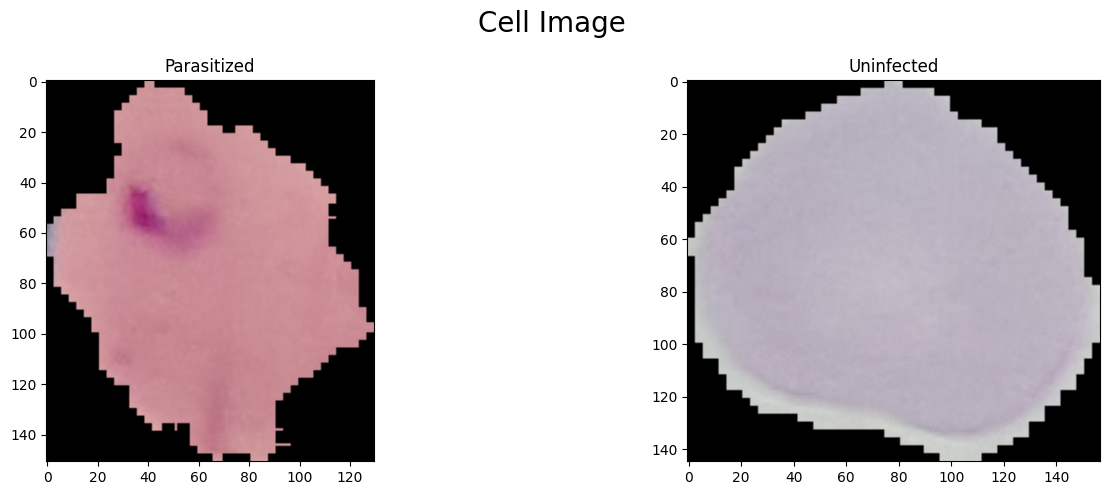

In [ ]:
import matplotlib.image as img


fig,ax=plt.subplots(ncols=2,figsize=(15,5))
fig.suptitle("Cell Image",fontsize=20)
Parasitized_img=img.imread(Parasitized[0])
Uninfected_img=img.imread(Uninfected[0])
for i,name in enumerate(list(data)):
    ax[i].set_title(name)
ax[0].imshow(Parasitized_img)
ax[1].imshow(Uninfected_img)
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
data_gen=ImageDataGenerator(rescale=1/255,validation_split=0.2)

In [ ]:
dir_path=r"/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images"

In [ ]:
train_data=data_gen.flow_from_directory(
    dir_path,
    target_size=(128,128),
    batch_size=16,
    class_mode="binary",
    subset="training"
)

Found 22048 images belonging to 2 classes.


In [ ]:
test_data=data_gen.flow_from_directory(
    dir_path,
    target_size=(128,128),
    batch_size=1,
    class_mode="binary",
    subset="validation"
)

Found 5510 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,BatchNormalization, Dropout


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    #First CNN Layer
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    #Second CNN Layer

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    #Third CNN Layer
    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    #fourth CNN Layer
    Conv2D(256, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    #Flatten

    Flatten(),

    # Dense Layers
    Dense(256, activation="relu"),
    Dropout(0.5),

    Dense(128, activation="relu"),
    Dropout(0.3),

    # Output Layer
    Dense(1, activation="sigmoid")
])

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,782,913 (10.62 MB)

 Trainable params: 2,781,953 (10.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5,
)

Epoch 1/5
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 428s 311ms/step - accuracy: 0.6010 - loss: 0.7268 - val_accuracy: 0.9203 - val_loss: 0.2920
Epoch 2/5
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 446s 324ms/step - accuracy: 0.9319 - loss: 0.2355 - val_accuracy: 0.9319 - val_loss: 0.2474
Epoch 3/5
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 457s 331ms/step - accuracy: 0.9518 - loss: 0.1730 - val_accuracy: 0.9423 - val_loss: 0.1966
Epoch 4/5
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 433s 314ms/step - accuracy: 0.9582 - loss: 0.1468 - val_accuracy: 0.9441 - val_loss: 0.1761
Epoch 5/5
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 442s 320ms/step - accuracy: 0.9540 - loss: 0.1565 - val_accuracy: 0.9495 - val_loss: 0.1781


In [ ]:
print("Validation Accuracy:",  model.evaluate(test_data))

5510/5510 ━━━━━━━━━━━━━━━━━━━━ 59s 11ms/step - accuracy: 0.9534 - loss: 0.1606
Validation Accuracy: [0.17805826663970947, 0.9495462775230408]


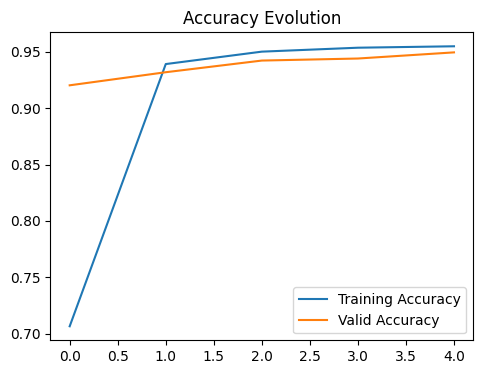

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Valid Accuracy')
plt.title('Accuracy Evolution')
plt.legend()
plt.show()

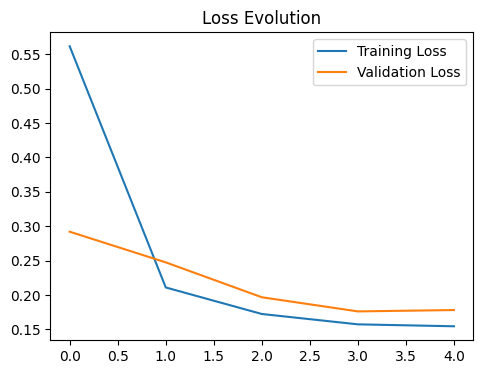

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.title("Loss Evolution")
plt.legend()
plt.show()